In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier



# **A.** Visualize the dataset in tabular form to understand and report the feature names, number of samples, feature dimensions, class distribution.

In [27]:

df_30 = pd.read_csv("Dataset/Data/features_30_sec.csv")
df_3 = pd.read_csv("Dataset/Data/features_3_sec.csv")

print("30-sec dataset shape:", df_30.shape)
print("3-sec dataset shape:", df_3.shape)

df_30.head()

30-sec dataset shape: (1000, 60)
3-sec dataset shape: (9990, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [28]:
df_3.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


=========================================================30-sec data Features and Class Distribution==========================================
Feature Names:
 ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc

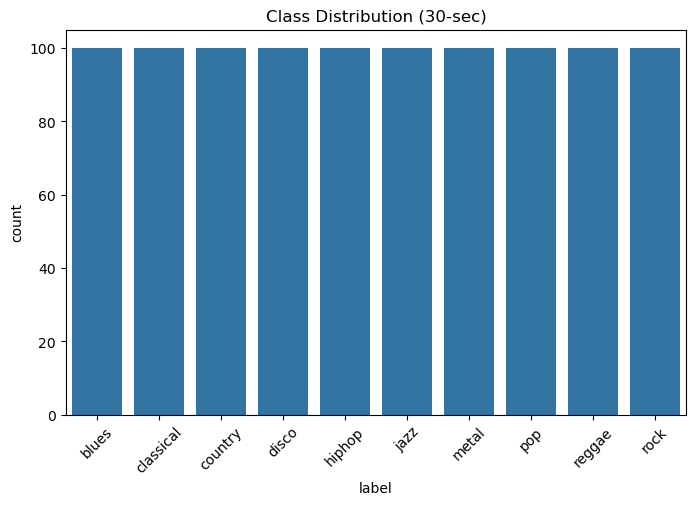

=========================================================3-sec data Features and Class Distribution==========================================
Feature Names:
 ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc1

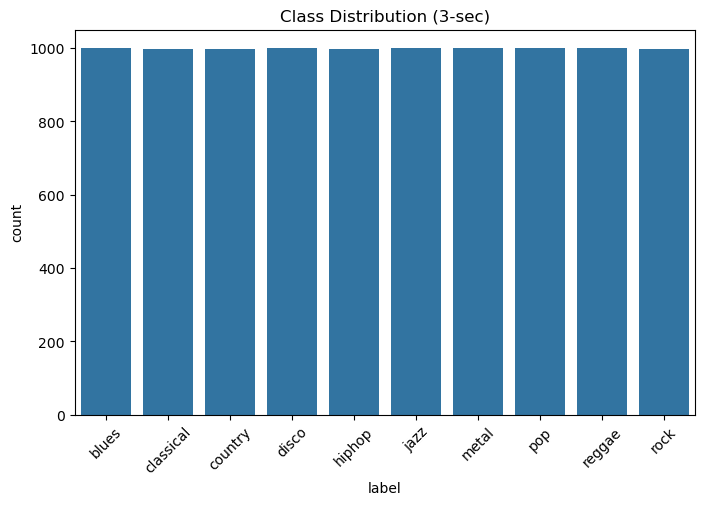

In [29]:
print("=========================================================30-sec data Features and Class Distribution==========================================")
print("Feature Names:\n", df_30.columns.tolist())
print("\nNumber of samples (30-sec):", len(df_30))
print("\nFeature dimension (30-sec):", df_30.shape[1] - 1)
plt.figure(figsize=(8,5))
sns.countplot(x=df_30['label'])
plt.title("Class Distribution (30-sec)")
plt.xticks(rotation=45)
plt.show()

print("=========================================================3-sec data Features and Class Distribution==========================================")
print("Feature Names:\n", df_30.columns.tolist())
print("\nNumber of samples (3-sec):", len(df_3))
print("\nFeature dimension (3-sec):", df_3.shape[1] - 1)
plt.figure(figsize=(8,5))
sns.countplot(x=df_3['label'])
plt.title("Class Distribution (3-sec)")
plt.xticks(rotation=45)
plt.show()

In [30]:

#  Label Encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
all_labels = pd.concat([df_30['label'], df_3['label']])
le.fit(all_labels)

df_30['label'] = le.transform(df_30['label'])
df_3['label'] = le.transform(df_3['label'])


#  Split features and labels
X30 = df_30.drop('label', axis=1)
y30 = df_30['label']

X3 = df_3.drop('label', axis=1)
y3 = df_3['label']

In [31]:
df_3['song_id'] = df_3['filename'].apply(lambda x: x.split('.')[0] + "_" + x.split('.')[1])
df_30['song_id'] = df_30['filename'].apply(lambda x: x.split('.')[0] + "_" + x.split('.')[1])

song_ids = df_30['song_id'].unique()
train_ids, test_ids = train_test_split(
    song_ids, test_size=0.2, random_state=42
)

# 30-sec split
train_mask_30 = df_30['song_id'].isin(train_ids)
test_mask_30 = df_30['song_id'].isin(test_ids)

X30_train = X30[train_mask_30]
X30_test = X30[test_mask_30]
y30_train = y30[train_mask_30]
y30_test = y30[test_mask_30]

#  3-sec split 
train_mask_3 = df_3['song_id'].isin(train_ids)
test_mask_3 = df_3['song_id'].isin(test_ids)

X3_train = X3[train_mask_3]
X3_test = X3[test_mask_3]
y3_train = y3[train_mask_3]
y3_test = y3[test_mask_3]

song_test_ids = df_3['song_id'][test_mask_3].values
# 30-sec
if 'filename' in X30_train.columns:
    X30_train = X30_train.drop(columns=['filename'])
    X30_test = X30_test.drop(columns=['filename'])

# 3-sec
if 'filename' in X3_train.columns:
    X3_train = X3_train.drop(columns=['filename'])
    X3_test = X3_test.drop(columns=['filename'])

print(len(set(song_test_ids))) 
print(len(X3_test))             

200
1997


# **B.** Train machine learning models like SVM, Random Forest, Gradient Boosting on both 3sec and 30 sec dataset

In [32]:

# 30-sec scaling
scaler_30 = StandardScaler()
X30_train = scaler_30.fit_transform(X30_train)
X30_test = scaler_30.transform(X30_test)

# 3-sec scaling
scaler_3 = StandardScaler()
X3_train = scaler_3.fit_transform(X3_train)
X3_test = scaler_3.transform(X3_test)

# Random Forest
rf_30 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_30.fit(X30_train, y30_train)

# SVM 
svm_30 = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_30.fit(X30_train, y30_train)

# Predictions
rf_pred_30 = rf_30.predict(X30_test)
svm_pred_30 = svm_30.predict(X30_test)

# Metrics
print("Random Forest (30-sec)")
print("Accuracy:", accuracy_score(y30_test, rf_pred_30))
print("F1 Score:", f1_score(y30_test, rf_pred_30, average='macro'))

print("\nSVM (30-sec)")
print("Accuracy:", accuracy_score(y30_test, svm_pred_30))
print("F1 Score:", f1_score(y30_test, svm_pred_30, average='macro'))

Random Forest (30-sec)
Accuracy: 0.775
F1 Score: 0.7786248872840955

SVM (30-sec)
Accuracy: 0.74
F1 Score: 0.7344246410759425


In [33]:

# Train models on 3-sec data
rf_3 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_3.fit(X3_train, y3_train)

svm_3 = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_3.fit(X3_train, y3_train)

rf_pred_3 = rf_3.predict(X3_test)
svm_pred_3 = svm_3.predict(X3_test)

# Metrics 
print("Random Forest (3-sec - Segment Level)")
print("Accuracy:", accuracy_score(y3_test, rf_pred_3))
print("F1 Score:", f1_score(y3_test, rf_pred_3, average='macro'))

print("\nSVM (3-sec - Segment Level)")
print("Accuracy:", accuracy_score(y3_test, svm_pred_3))
print("F1 Score:", f1_score(y3_test, svm_pred_3, average='macro'))

Random Forest (3-sec - Segment Level)
Accuracy: 0.6735102653980971
F1 Score: 0.6697275605787152

SVM (3-sec - Segment Level)
Accuracy: 0.7080620931397096
F1 Score: 0.6985229123024237


In [34]:
gb_30 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
gb_30.fit(X30_train, y30_train)

gb_pred_30 = gb_30.predict(X30_test)

print("\nGradient Boosting (30-sec)")
print("Accuracy:", accuracy_score(y30_test, gb_pred_30))
print("F1 Score:", f1_score(y30_test, gb_pred_30, average='macro'))


Gradient Boosting (30-sec)
Accuracy: 0.755
F1 Score: 0.7619635823114084


In [35]:
gb_3 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
gb_3.fit(X3_train, y3_train)

gb_pred_3 = gb_3.predict(X3_test)
gb_probs_3 = gb_3.predict_proba(X3_test)

print("\nGradient Boosting (3-sec)")
print("Accuracy:", accuracy_score(y3_test, gb_pred_3))
print("F1 Score:", f1_score(y3_test, gb_pred_3, average='macro'))


Gradient Boosting (3-sec)
Accuracy: 0.6810215322984476
F1 Score: 0.680087041000107


In [36]:
def aggregate_predictions(probs, song_ids, y_true, method="mean"):
    song_dict = defaultdict(list)
    label_dict = {}

    for i in range(len(probs)):
        sid = song_ids[i]
        song_dict[sid].append(probs[i])
        label_dict[sid] = y_true[i]

    final_preds = []
    final_true = []

    for sid in song_dict:
        prob_list = np.array(song_dict[sid])

        if method == "mean":
            pred = np.argmax(prob_list.mean(axis=0))
        else:
            pred = np.bincount(np.argmax(prob_list, axis=1)).argmax()

        final_preds.append(pred)
        final_true.append(label_dict[sid])

    return final_true, final_preds

print("=========================================================3-sec Dataset==========================================")

# RF
rf_probs = rf_3.predict_proba(X3_test)
y_true_rf_3, rf_mean_3 = aggregate_predictions(rf_probs, song_test_ids, y3_test.values, "mean")
_, rf_vote_3 = aggregate_predictions(rf_probs, song_test_ids, y3_test.values, "vote")

# SVM
svm_probs = svm_3.predict_proba(X3_test)
y_true_svm_3, svm_mean_3 = aggregate_predictions(svm_probs, song_test_ids, y3_test.values, "mean")
_, svm_vote_3 = aggregate_predictions(svm_probs, song_test_ids, y3_test.values, "vote")


print("RF Mean:", accuracy_score(y_true_rf_3, rf_mean_3))
print("RF Vote:", accuracy_score(y_true_rf_3, rf_vote_3))

print("SVM Mean:", accuracy_score(y_true_svm_3, svm_mean_3))
print("SVM Vote:", accuracy_score(y_true_svm_3, svm_vote_3))

print("=========================================================30-sec data Features and Class Distribution==========================================")
# RF
rf_probs = rf_30.predict_proba(X30_test)
y_true_rf_30, rf_mean_30 = aggregate_predictions(rf_probs, song_test_ids, y30_test.values, "mean")
_, rf_vote_30 = aggregate_predictions(rf_probs, song_test_ids, y30_test.values, "vote")

# SVM
svm_probs = svm_30.predict_proba(X30_test)
y_true_svm_30, svm_mean_30 = aggregate_predictions(svm_probs, song_test_ids, y30_test.values, "mean")
_, svm_vote_30 = aggregate_predictions(svm_probs, song_test_ids, y30_test.values, "vote")


print("RF Mean:", accuracy_score(y_true_rf_30, rf_mean_30))
print("RF Vote:", accuracy_score(y_true_rf_30, rf_vote_30))

print("SVM Mean:", accuracy_score(y_true_svm_30, svm_mean_30))
print("SVM Vote:", accuracy_score(y_true_svm_30, svm_vote_30))


=========================================================3-sec Dataset==========================================
RF Mean: 0.73
RF Vote: 0.72
SVM Mean: 0.785
SVM Vote: 0.79
=========================================================30-sec data Features and Class Distribution==========================================
RF Mean: 0.8
RF Vote: 0.8
SVM Mean: 0.8
SVM Vote: 0.8


In [37]:
# 3-sec Gradient Boosting
gb_probs_3 = gb_3.predict_proba(X3_test)

y_true_gb, gb_mean = aggregate_predictions(
    gb_probs_3, song_test_ids, y3_test.values, method="mean"
)

_, gb_vote = aggregate_predictions(
    gb_probs_3, song_test_ids, y3_test.values, method="vote"
)

print("\nGradient Boosting (3-sec Song-Level)")

print("Mean Accuracy:", accuracy_score(y_true_gb, gb_mean))
print("Mean F1:", f1_score(y_true_gb, gb_mean, average='macro'))

print("Vote Accuracy:", accuracy_score(y_true_gb, gb_vote))
print("Vote F1:", f1_score(y_true_gb, gb_vote, average='macro'))

# 30-sec Gradient Boosting 

gb_probs_30 = gb_30.predict_proba(X30_test)
song_ids_30 = np.arange(len(X30_test))

y_true_gb_30, gb_mean_30 = aggregate_predictions(
    gb_probs_30, song_ids_30, y30_test.values, method="mean"
)

_, gb_vote_30 = aggregate_predictions(
    gb_probs_30, song_ids_30, y30_test.values, method="vote"
)

print("\nGradient Boosting (30-sec)")

print("Mean Accuracy:", accuracy_score(y_true_gb_30, gb_mean_30))
print("Mean F1:", f1_score(y_true_gb_30, gb_mean_30, average='macro'))

print("Vote Accuracy:", accuracy_score(y_true_gb_30, gb_vote_30))
print("Vote F1:", f1_score(y_true_gb_30, gb_vote_30, average='macro'))


Gradient Boosting (3-sec Song-Level)
Mean Accuracy: 0.765
Mean F1: 0.7645053542028502
Vote Accuracy: 0.745
Vote F1: 0.7469436077784248

Gradient Boosting (30-sec)
Mean Accuracy: 0.755
Mean F1: 0.7619635823114084
Vote Accuracy: 0.755
Vote F1: 0.7619635823114084


# **C.** For both datasets, report the Classification Accuracy, Macro F1-score and Confusion Matrix. 

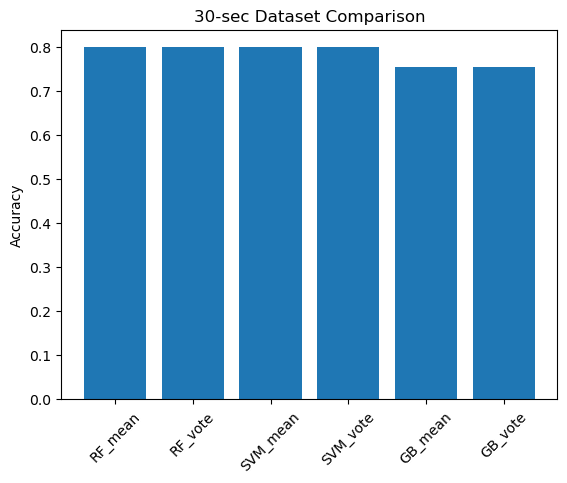

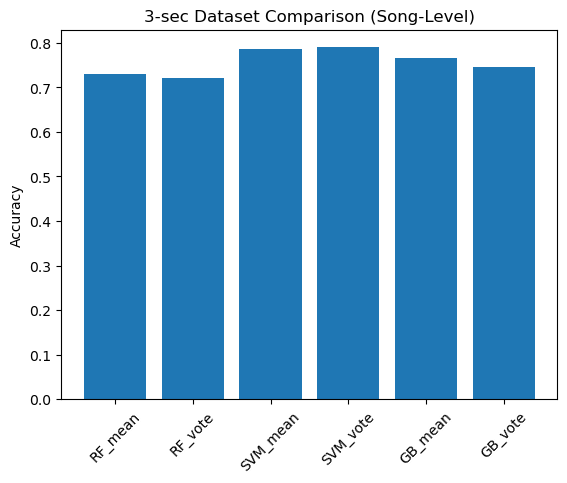


============= FINAL RESULTS =============
RF_mean_3: 0.7300
RF_vote_3: 0.7200
SVM_mean_3: 0.7850
SVM_vote_3: 0.7900
GB_mean_3: 0.7650
GB_vote_3: 0.7450
RF_mean_30: 0.8000
RF_vote_30: 0.8000
SVM_mean_30: 0.8000
SVM_vote_30: 0.8000
GB_mean_30: 0.7550
GB_vote_30: 0.7550

============= F1 SCORES =============
RF_mean_3: 0.7215
RF_vote_3: 0.7170
SVM_mean_3: 0.7766
SVM_vote_3: 0.7812
GB_mean_3: 0.7645
GB_vote_3: 0.7469
RF_mean_30: 0.7933
RF_vote_30: 0.7933
SVM_mean_30: 0.7933
SVM_vote_30: 0.7933
GB_mean_30: 0.7620
GB_vote_30: 0.7620


In [40]:
results = {
    # 3-sec
    "RF_mean_3": accuracy_score(y_true_rf_3, rf_mean_3),
    "RF_vote_3": accuracy_score(y_true_rf_3, rf_vote_3),

    "SVM_mean_3": accuracy_score(y_true_svm_3, svm_mean_3),
    "SVM_vote_3": accuracy_score(y_true_svm_3, svm_vote_3),

    "GB_mean_3": accuracy_score(y_true_gb, gb_mean),
    "GB_vote_3": accuracy_score(y_true_gb, gb_vote),

    # 30-sec
    "RF_mean_30": accuracy_score(y_true_rf_30, rf_mean_30),
    "RF_vote_30": accuracy_score(y_true_rf_30, rf_vote_30),

    "SVM_mean_30": accuracy_score(y_true_svm_30, svm_mean_30),
    "SVM_vote_30": accuracy_score(y_true_svm_30, svm_vote_30),

    "GB_mean_30": accuracy_score(y_true_gb_30, gb_mean_30),
    "GB_vote_30": accuracy_score(y_true_gb_30, gb_vote_30),
}

#  F1 SCORES
results_f1 = {
    "RF_mean_3": f1_score(y_true_rf_3, rf_mean_3, average='macro'),
    "RF_vote_3": f1_score(y_true_rf_3, rf_vote_3, average='macro'),

    "SVM_mean_3": f1_score(y_true_svm_3, svm_mean_3, average='macro'),
    "SVM_vote_3": f1_score(y_true_svm_3, svm_vote_3, average='macro'),

    "GB_mean_3": f1_score(y_true_gb, gb_mean, average='macro'),
    "GB_vote_3": f1_score(y_true_gb, gb_vote, average='macro'),

    "RF_mean_30": f1_score(y_true_rf_30, rf_mean_30, average='macro'),
    "RF_vote_30": f1_score(y_true_rf_30, rf_vote_30, average='macro'),

    "SVM_mean_30": f1_score(y_true_svm_30, svm_mean_30, average='macro'),
    "SVM_vote_30": f1_score(y_true_svm_30, svm_vote_30, average='macro'),

    "GB_mean_30": f1_score(y_true_gb_30, gb_mean_30, average='macro'),
    "GB_vote_30": f1_score(y_true_gb_30, gb_vote_30, average='macro'),
}

# 30-sec GRAPH 
methods_30 = ["RF_mean", "RF_vote", "SVM_mean", "SVM_vote", "GB_mean", "GB_vote"]
scores_30 = [
    results["RF_mean_30"],
    results["RF_vote_30"],
    results["SVM_mean_30"],
    results["SVM_vote_30"],
    results["GB_mean_30"],
    results["GB_vote_30"]
]

plt.figure()
plt.bar(methods_30, scores_30)
plt.title("30-sec Dataset Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


#  3-sec GRAPH 
methods_3 = ["RF_mean", "RF_vote", "SVM_mean", "SVM_vote", "GB_mean", "GB_vote"]
scores_3 = [
    results["RF_mean_3"],
    results["RF_vote_3"],
    results["SVM_mean_3"],
    results["SVM_vote_3"],
    results["GB_mean_3"],
    results["GB_vote_3"]
]

plt.figure()
plt.bar(methods_3, scores_3)
plt.title("3-sec Dataset Comparison (Song-Level)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

print("\n============= FINAL RESULTS =============")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

print("\n============= F1 SCORES =============")
for k, v in results_f1.items():
    print(f"{k}: {v:.4f}")

In [42]:
def plot_cm(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.show()


============= Confusion Matrices (3-sec Song-Level) =============


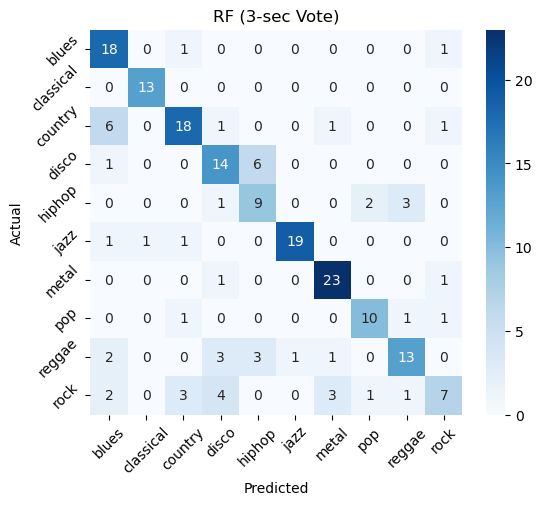

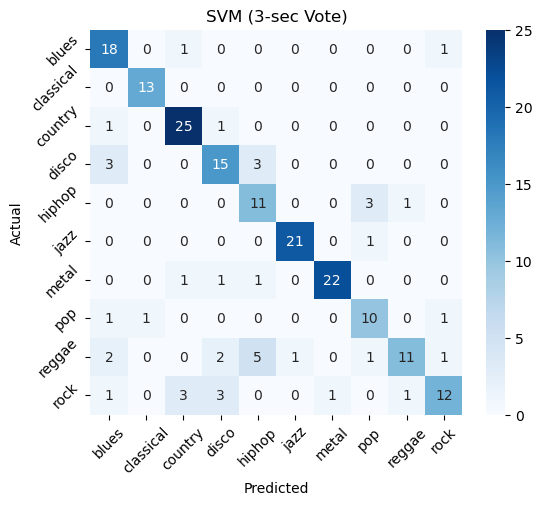

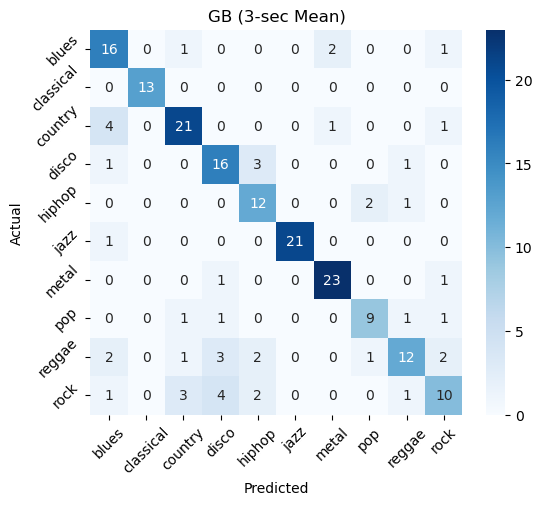

In [41]:
print("\n============= Confusion Matrices (3-sec Song-Level) =============")
plot_cm(y_true_rf_3, rf_vote_3, "RF (3-sec Vote)", class_names)
plot_cm(y_true_svm_3, svm_vote_3, "SVM (3-sec Vote)", class_names)
plot_cm(y_true_gb, gb_mean, "GB (3-sec Mean)", class_names)


============= Confusion Matrices (30-sec) =============


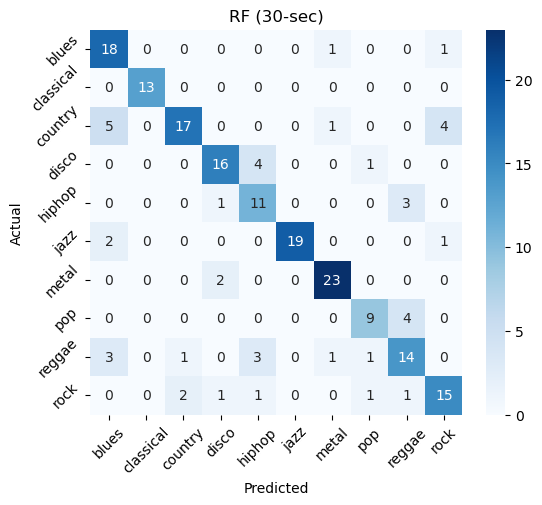

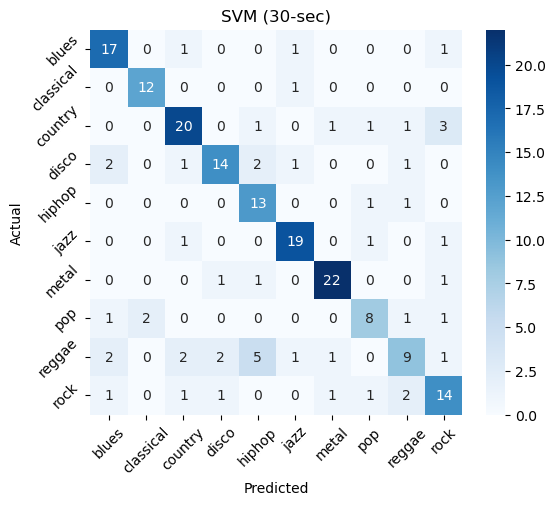

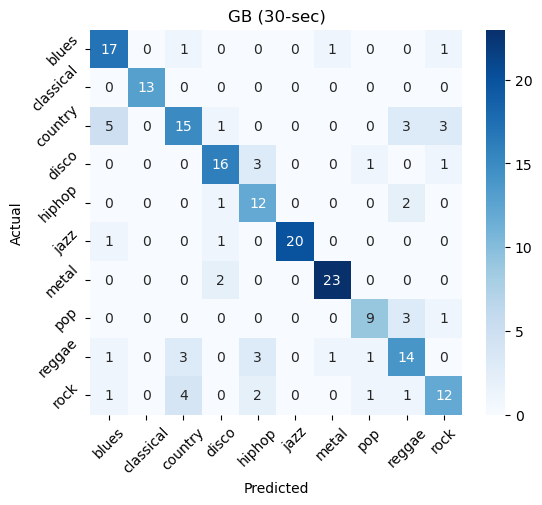

In [43]:
print("\n============= Confusion Matrices (30-sec) =============")

plot_cm(y30_test, rf_pred_30, "RF (30-sec)", class_names)
plot_cm(y30_test, svm_pred_30, "SVM (30-sec)", class_names)
plot_cm(y30_test, gb_pred_30, "GB (30-sec)", class_names)